In [7]:
import pandas as pd
file_path = "C:/Users/vnish/Downloads/Customer Profitability & Purchase Pattern Analysis/Data/online_retail raw.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# Drop rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Filter out rows with negative or zero Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Filter out cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],dayfirst=True)

# Create a TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Display basic stats and sample
df_cleaned_info = df.info()
df_cleaned_head = df.head(10)
df_cleaned_description = df.describe()

df_cleaned_info, df_cleaned_head, df_cleaned_description

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


(None,
   InvoiceNo StockCode                          Description  Quantity  \
 0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
 1    536365     71053                  WHITE METAL LANTERN         6   
 2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
 3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
 4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
 5    536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
 6    536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
 7    536366     22633               HAND WARMER UNION JACK         6   
 8    536366     22632            HAND WARMER RED POLKA DOT         6   
 9    536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   
 
           InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
 0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
 1 2010-12-01 08:26:00       3.39   

C:\Users\vnish\AppData\Local\Temp\ipykernel_14704\1170079006.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


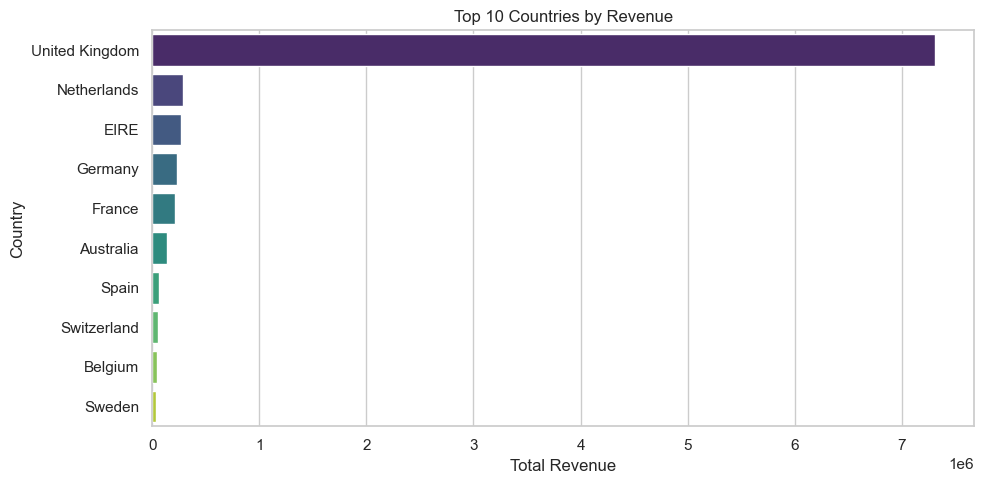

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top 10 Countries by Revenue
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

C:\Users\vnish\AppData\Local\Temp\ipykernel_14704\2438218659.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="magma")


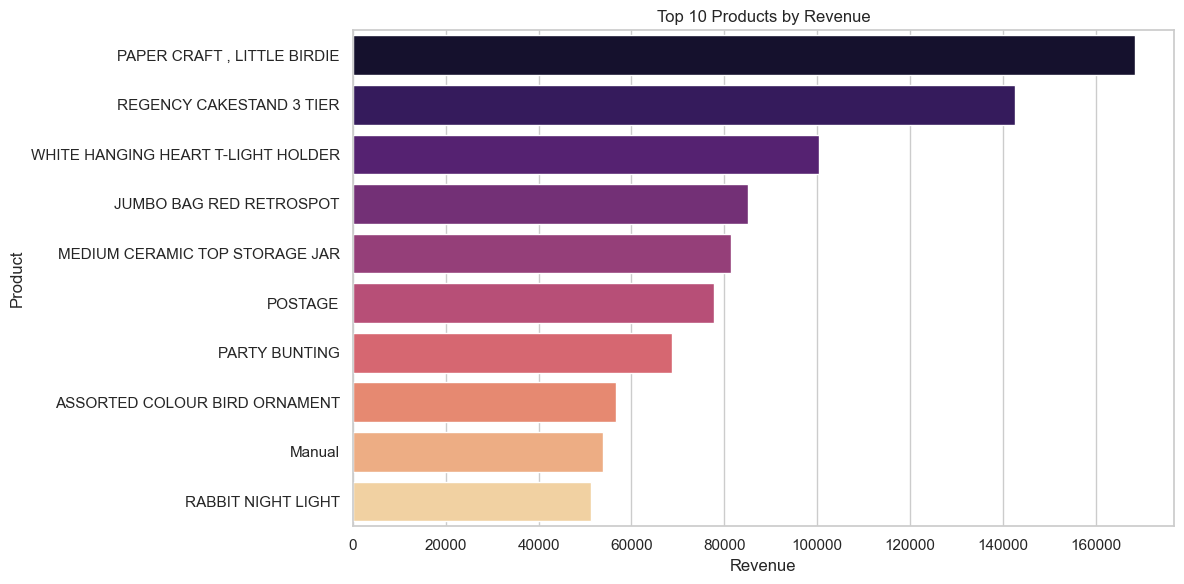

In [11]:
# 2. Top 10 Selling Products
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette="magma")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

C:\Users\vnish\AppData\Local\Temp\ipykernel_14704\2383828025.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index('InvoiceDate').resample('M')['TotalPrice'].sum()


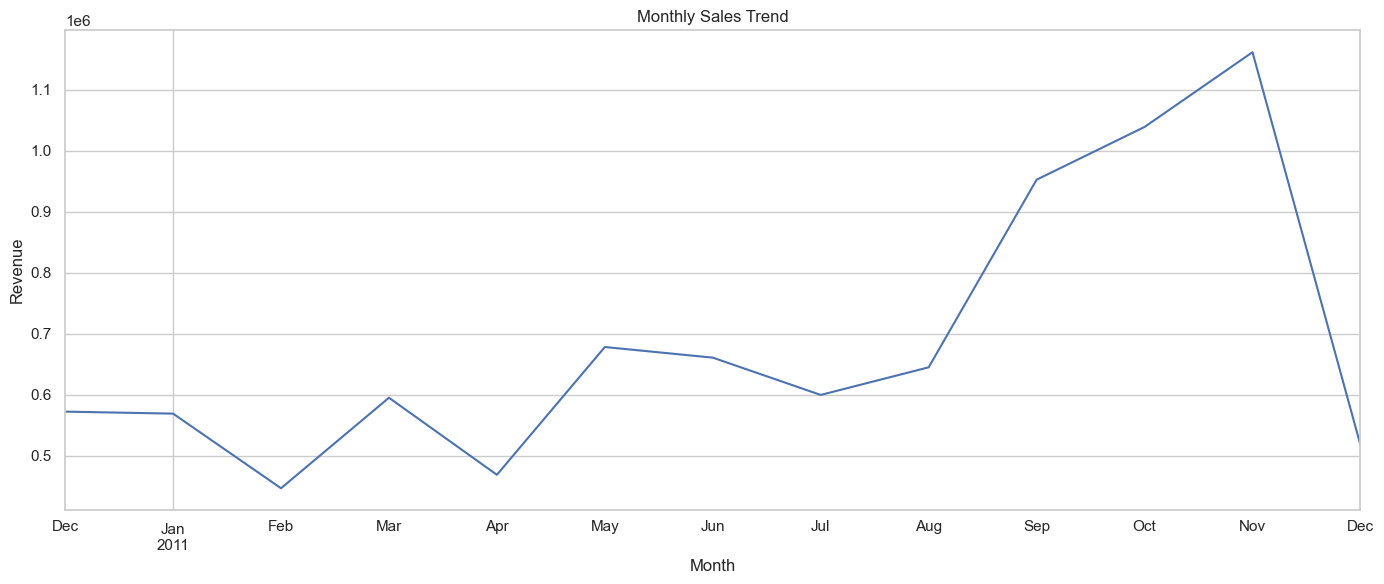

In [12]:
# 3. Monthly Sales Trend
monthly_sales = df.set_index('InvoiceDate').resample('M')['TotalPrice'].sum()

plt.figure(figsize=(14, 6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()


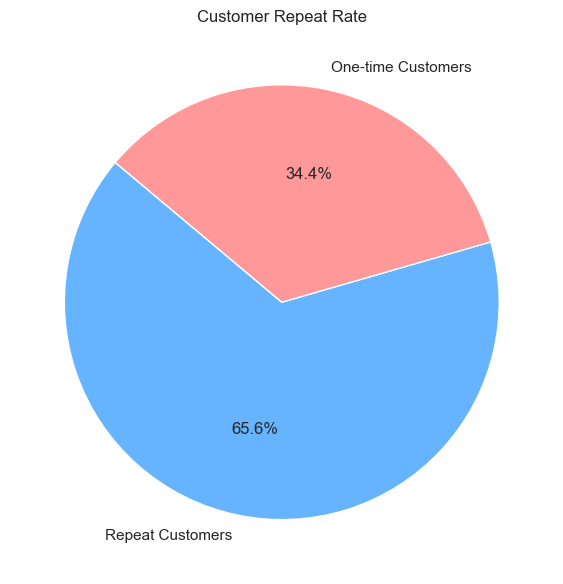

In [15]:
# 4. Repeat vs One-Time Customers
customer_order_counts = df.groupby('CustomerID')['InvoiceNo'].nunique()
repeat_customers = customer_order_counts[customer_order_counts > 1].count()
one_time_customers = customer_order_counts[customer_order_counts == 1].count()

plt.figure(figsize=(6, 6))
plt.pie([repeat_customers, one_time_customers],
        labels=['Repeat Customers', 'One-time Customers'],
        autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'],
        startangle=140)
plt.title("Customer Repeat Rate")
plt.tight_layout()
plt.show()

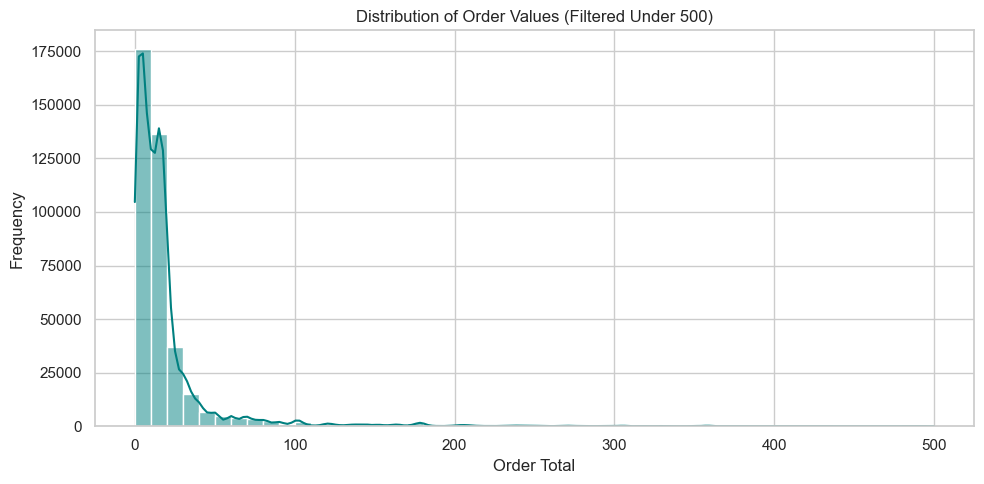

: 

In [ ]:
# Filter to realistic order values (to avoid outliers affecting the plot)
filtered_df = df[df['TotalPrice'] <= 500]

plt.figure(figsize=(10, 5))
sns.histplot(filtered_df['TotalPrice'], bins=50, kde=True, color="teal")
plt.title("Distribution of Order Values (Filtered Under 500)")
plt.xlabel("Order Total")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()